# Velocity Manifold Fitting Demo on Pancreas Dataset

This notebook demonstrates velocity-aware manifold fitting on the pancreas single-cell RNA velocity dataset, comparing five different methods without ground truth. We evaluate based on visualization and downstream metrics.

## Import Libraries and Load Pancreas Data

Import required libraries and load the pancreas dataset.

In [14]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Literal, Tuple

import numpy as np
import pandas as pd
from numpy.linalg import norm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from IPython.display import display

import scvelo as scv
import scanpy as sc

Array = np.ndarray

@dataclass
class VMFParams:
    k: int = 30
    d: int = 2
    n_iter: int = 10
    theta: float = 0.20
    gamma: float = 8.0
    beta: float = 2.0
    kappa: float = 1.0
    eta_g: float = 0.35
    cv: float = 0.12
    max_step_frac: float = 0.30
    random_state: int = 0

def _row_norm(X: Array, eps: float = 1e-12) -> Array:
    return np.sqrt(np.sum(X * X, axis=1, keepdims=True)) + eps

def _cosine_rows(a: Array, b: Array, eps: float = 1e-12) -> Array:
    return np.sum(a * b, axis=1) / ((_row_norm(a, eps)[:, 0]) * (_row_norm(b, eps)[:, 0]) + eps)

def _sigmoid(x: Array) -> Array:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))

def build_velocity_aware_knn(X: Array, W: Array, params: VMFParams) -> Array:
    n = X.shape[0]
    cand_k = min(n - 1, max(params.k * 4, params.k + 5))
    nn = NearestNeighbors(n_neighbors=cand_k + 1).fit(X)
    _, cand = nn.kneighbors(X)
    cand = cand[:, 1:]

    N = np.zeros((n, params.k), dtype=int)
    for i in range(n):
        J = cand[i]
        disp = X[J] - X[i]
        dist = norm(disp, axis=1)
        cos = _cosine_rows(np.repeat(W[i][None, :], len(J), axis=0), disp)
        score = (1 - params.theta) * dist + params.theta * (1 - _sigmoid(params.gamma * cos))
        N[i] = J[np.argsort(score)[: params.k]]
    return N

def local_pca_projector(Z: Array, N: Array, weights: Array, d: int) -> Tuple[Array, Array]:
    n, D = Z.shape
    U_all = np.zeros((n, D, d))
    P_all = np.zeros((n, D, D))
    for i in range(n):
        J = N[i]
        C = Z[J] - Z[i]
        w = weights[i][:, None]
        M = (C * w).T @ C
        vals, vecs = np.linalg.eigh(M)
        U = vecs[:, np.argsort(vals)[::-1][:d]]
        U_all[i] = U
        P_all[i] = U @ U.T
    return U_all, P_all

def compute_weights(Z: Array, W: Array, N: Array, params: VMFParams) -> Tuple[Array, Array]:
    n = Z.shape[0]
    K = N.shape[1]
    weights = np.zeros((n, K))
    h = np.zeros(n)
    for i in range(n):
        J = N[i]
        disp = Z[J] - Z[i]
        dist = norm(disp, axis=1)
        h_i = np.max(dist) + 1e-12
        h[i] = h_i
        radial = np.maximum(1 - (dist / h_i) ** 2, 0.0) ** params.beta
        cos_abs = np.abs(_cosine_rows(np.repeat(W[i][None, :], K, axis=0), disp))
        directional = np.exp(params.kappa * cos_abs)
        w = radial * directional + 1e-12
        weights[i] = w / np.sum(w)
    return weights, h

def project_velocity(W: Array, P: Array) -> Array:
    return np.einsum("nij,nj->ni", P, W)

def fit_velocity_mf(
    X: Array,
    W: Array,
    params: VMFParams,
    mode: Literal["original", "normal_only", "geometric_only", "bidirectional_velocity"] = "original",
    freeze_graph: bool = True,
) -> Dict[str, Array]:
    Z = X.copy()
    Wcur = W.copy()

    N = build_velocity_aware_knn(Z, Wcur, params)

    for t in range(params.n_iter):
        if (not freeze_graph) and t > 0:
            N = build_velocity_aware_knn(Z, Wcur, params)

        weights, h = compute_weights(Z, Wcur, N, params)
        U, P = local_pca_projector(Z, N, weights, params.d)
        Vproj = project_velocity(Wcur, P)

        Z_new = Z.copy()
        for i in range(Z.shape[0]):
            J = N[i]
            m_i = np.sum(weights[i][:, None] * Z[J], axis=0)
            g_i = m_i - Z[i]

            step_cap = params.max_step_frac * h[i]
            if mode == "original":
                vdir = Vproj[i] / (norm(Vproj[i]) + 1e-12)
                step = params.eta_g * g_i + params.cv * h[i] * vdir
            elif mode == "normal_only":
                normal_g = g_i - P[i] @ g_i
                step = params.eta_g * normal_g
            elif mode == "geometric_only":
                step = params.eta_g * g_i
            elif mode == "bidirectional_velocity":
                cosine = _cosine_rows(Vproj[i][None, :], g_i[None, :])[0]
                vdir = Vproj[i] / (norm(Vproj[i]) + 1e-12)
                if cosine <= 0:
                    vdir = -vdir
                step = params.eta_g * g_i + params.cv * h[i] * vdir
            else:
                raise ValueError("Invalid mode")

            s_norm = norm(step)
            if s_norm > step_cap:
                step = step * (step_cap / (s_norm + 1e-12))
            Z_new[i] = Z[i] + step

        Z = Z_new
        Wcur = Vproj

    weights, h = compute_weights(Z, Wcur, N, params)
    U, P = local_pca_projector(Z, N, weights, params.d)
    Vproj = project_velocity(W, P)
    return {"Z": Z, "V": Vproj, "N": N, "U": U, "P": P}

def make_pancreas():
    print("Loading Pancreas dataset...")
    adata = scv.datasets.pancreas()
    
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    
    scv.tl.velocity(adata, mode='stochastic')
    
    scv.tl.velocity_graph(adata)
    scv.tl.velocity_embedding(adata, basis='pca')
    
    # Compute UMAP for later use
    sc.tl.umap(adata)
    scv.tl.velocity_embedding(adata, basis='umap')
    
    X = adata.obsm['X_pca']
    W = adata.obsm['velocity_pca']
    
    plot_labels = adata.obs['clusters']
    
    X0 = X
    V0 = W
    
    return adata, X, W, X0, V0, plot_labels, plot_labels

## Preprocess Data and Compute RNA Velocity

Load and preprocess the pancreas data, compute RNA velocity.

In [15]:
# Load pancreas data
adata, X, W, X0, V0, plot_labels, mix_labels = make_pancreas()

print(f"Data shape: X {X.shape}, W {W.shape}")
print(f"Clusters: {plot_labels.unique()}")

Loading Pancreas dataset...
Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/opt/anaconda3/lib/python3.13/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/_s/ktcwp8x150zfnqp1_mp4hs9r0000gn/T/ipykernel_60630/2233641160.py:157: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/opt/anaconda3/lib/python3.13/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


/opt/anaconda3/lib/python3.13/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
Data shape: X (3696, 50), W (3696, 50)
Clusters: ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']
Categories (8, object): ['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta', 'Alpha', 'Delta', 'Epsilon']


In [16]:
def velocity_cosine(Vhat: Array, Vtrue: Array) -> float:
    c = _cosine_rows(Vhat, Vtrue)
    return float(np.nanmean(c))

def rmse_to_truth(Z: Array, X0: Array) -> float:
    return float(np.sqrt(np.mean(np.sum((Z - X0) ** 2, axis=1))))

def knn_preservation(X: Array, Z: Array, k: int = 20) -> float:
    I1 = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(return_distance=False)[:, 1:]
    I2 = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(return_distance=False)[:, 1:]
    return float(np.mean([len(set(I1[i]).intersection(I2[i])) / k for i in range(X.shape[0])]))

def local_metric_distortion(X: Array, Z: Array, k: int = 20) -> float:
    I = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(return_distance=False)[:, 1:]
    vals = []
    for i in range(X.shape[0]):
        for j in I[i]:
            dx = norm(X[i] - X[j]) + 1e-12
            dz = norm(Z[i] - Z[j]) + 1e-12
            vals.append(abs(np.log(dz / dx)))
    return float(np.mean(vals))

def branch_mixing_score(Z: Array, labels: Array, k: int = 20) -> float:
    I = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(return_distance=False)[:, 1:]
    mix = np.mean([np.mean(labels[I[i]] != labels[i]) for i in range(Z.shape[0])])
    return float(mix)

def evaluate_no_gt(name: str, X: Array, W: Array, out: Dict[str, Array], labels=None) -> Dict[str, float]:
    Z, V = out["Z"], out["V"]
    row = {
        "method": name,
        "knn_preservation": knn_preservation(X, Z, k=20),
        "local_metric_distortion": local_metric_distortion(X, Z, k=20),
        "mean_displacement": float(np.mean(norm(Z - X, axis=1))),
        "velocity_cosine": velocity_cosine(V, W),  # compared to original velocity
    }
    if labels is not None:
        row["branch_mixing"] = branch_mixing_score(Z, labels, k=20)
    return row

## Define and Run Five Velocity Manifold Fitting Methods

Run the five methods on the pancreas data.

In [17]:
# Set parameters
params = VMFParams(k=30, d=2, n_iter=10, eta_g=0.35, cv=0.12, theta=0.20, max_step_frac=0.30)

# Run methods
print("Running original...")
original = fit_velocity_mf(X, W, params, mode="original")

print("Running normal_only...")
normal = fit_velocity_mf(X, W, params, mode="normal_only")

print("Running geometric_only...")
geometric_only = fit_velocity_mf(X, W, params, mode="geometric_only")

print("Running bidirectional_velocity...")
bidirectional = fit_velocity_mf(X, W, params, mode="bidirectional_velocity")

# Collect results
results = {
    "original": original,
    "normal_only": normal,
    "geometric_only": geometric_only,
    "bidirectional_velocity": bidirectional,
}

# Evaluate
rows = [
    evaluate_no_gt("raw", X, W, {"Z": X, "V": W}, mix_labels),
    evaluate_no_gt("original", X, W, original, mix_labels),
    evaluate_no_gt("normal_only", X, W, normal, mix_labels),
    evaluate_no_gt("geometric_only", X, W, geometric_only, mix_labels),
    evaluate_no_gt("bidirectional_velocity", X, W, bidirectional, mix_labels),
]

df = pd.DataFrame(rows)
display(df)

Running original...
Running normal_only...
Running geometric_only...
Running bidirectional_velocity...


,method,knn_preservation,local_metric_distortion,mean_displacement,velocity_cosine,branch_mixing
0,raw,1.000000,0.000000,0.000000,1.000000,0.138988
1,original,0.231426,0.824071,8.813048,0.650442,0.161472
2,normal_only,0.860133,0.026846,0.823509,0.459949,0.146050
3,geometric_only,0.385823,1.623930,6.912532,0.860508,0.111039
4,bidirectional_velocity,0.296686,1.723719,7.504897,0.848399,0.118899


## Visualize Velocity Streamlines on Embedding

Plot the results with velocity vectors on the PCA embedding.

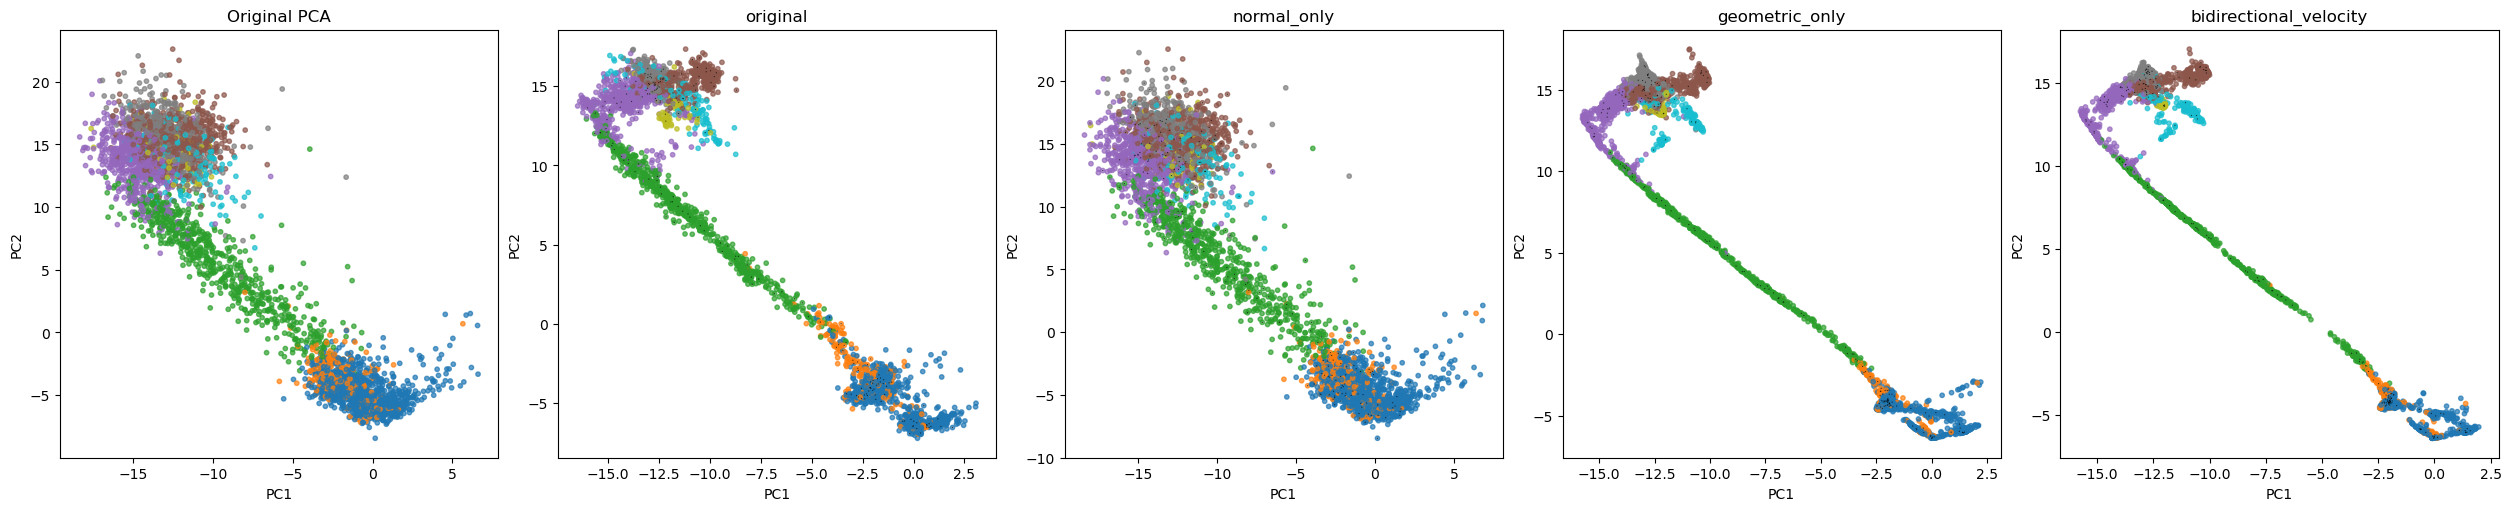

In [18]:
def plot_pancreas_results(X: Array, results: Dict[str, Dict[str, Array]], labels):
    ncols = 1 + len(results)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    # Use first 2 PCs
    X_plot = X[:, :2]
    # Convert categorical labels to numeric codes
    if hasattr(labels, 'cat'):
        color = labels.cat.codes
    else:
        color = labels
    axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
    axes[0].set_title("Original PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")

    for ax, (name, out) in zip(axes[1:], results.items()):
        Z = out["Z"]
        V = out["V"]
        Z_plot = Z[:, :2]
        V_plot = V[:, :2]
        ax.scatter(Z_plot[:, 0], Z_plot[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
        step = max(1, Z.shape[0] // 200)
        ax.quiver(
            Z_plot[::step, 0], Z_plot[::step, 1],
            V_plot[::step, 0], V_plot[::step, 1],
            angles="xy", scale_units="xy", scale=50, width=0.003, alpha=0.7
        )
        ax.set_title(name)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

    plt.show()

plot_pancreas_results(X, results, plot_labels)

## Downstream Analysis: Cluster Separation and Trajectory Coherence

Analyze cluster separation and trajectory coherence for each method.

In [19]:
# Downstream analysis: cluster separation
from sklearn.metrics import silhouette_score

def analyze_clusters(Z, labels):
    try:
        sil = silhouette_score(Z[:, :2], labels)
        return sil
    except:
        return np.nan

cluster_sep = {}
for name, out in results.items():
    Z = out["Z"]
    cluster_sep[name] = analyze_clusters(Z, plot_labels)

print("Cluster separation (silhouette score):")
for name, score in cluster_sep.items():
    print(f"{name}: {score:.3f}")

# Trajectory coherence: perhaps velocity magnitude consistency
vel_magnitude = {}
for name, out in results.items():
    V = out["V"]
    vel_magnitude[name] = np.mean(norm(V, axis=1))

print("\nAverage velocity magnitude:")
for name, mag in vel_magnitude.items():
    print(f"{name}: {mag:.3f}")

Cluster separation (silhouette score):
original: 0.134
normal_only: 0.023
geometric_only: 0.142
bidirectional_velocity: 0.161

Average velocity magnitude:
original: 0.265
normal_only: 0.182
geometric_only: 0.346
bidirectional_velocity: 0.341


## No-Ground-Truth Metrics: Velocity Consistency and Embedding Stability

Compute metrics without ground truth: KNN preservation, local distortion, displacement, velocity cosine, branch mixing.

In [9]:
# The metrics are already computed in df
display(df)

# Summary
print("Summary:")
print("- KNN preservation: higher is better (preserves local structure)")
print("- Local metric distortion: lower is better (less distortion)")
print("- Mean displacement: indicates how much points moved")
print("- Velocity cosine: similarity to original velocity")
print("- Branch mixing: lower is better (better cluster separation)")

,method,knn_preservation,local_metric_distortion,mean_displacement,velocity_cosine,branch_mixing
0,raw,1.000000,0.000000,0.000000,1.000000,0.138988
1,original,0.231426,0.824071,8.813048,0.650442,0.161472
2,normal_only,0.860133,0.026846,0.823509,0.459949,0.146050
3,geometric_only,0.385823,1.623930,6.912532,0.860508,0.111039
4,bidirectional_velocity,0.296686,1.723719,7.504897,0.848399,0.118899


Summary:
- KNN preservation: higher is better (preserves local structure)
- Local metric distortion: lower is better (less distortion)
- Mean displacement: indicates how much points moved
- Velocity cosine: similarity to original velocity
- Branch mixing: lower is better (better cluster separation)


## Alternative Visualization: UMAP Embedding

Use UMAP for non-linear dimensionality reduction to better preserve local structure and visualize differences.

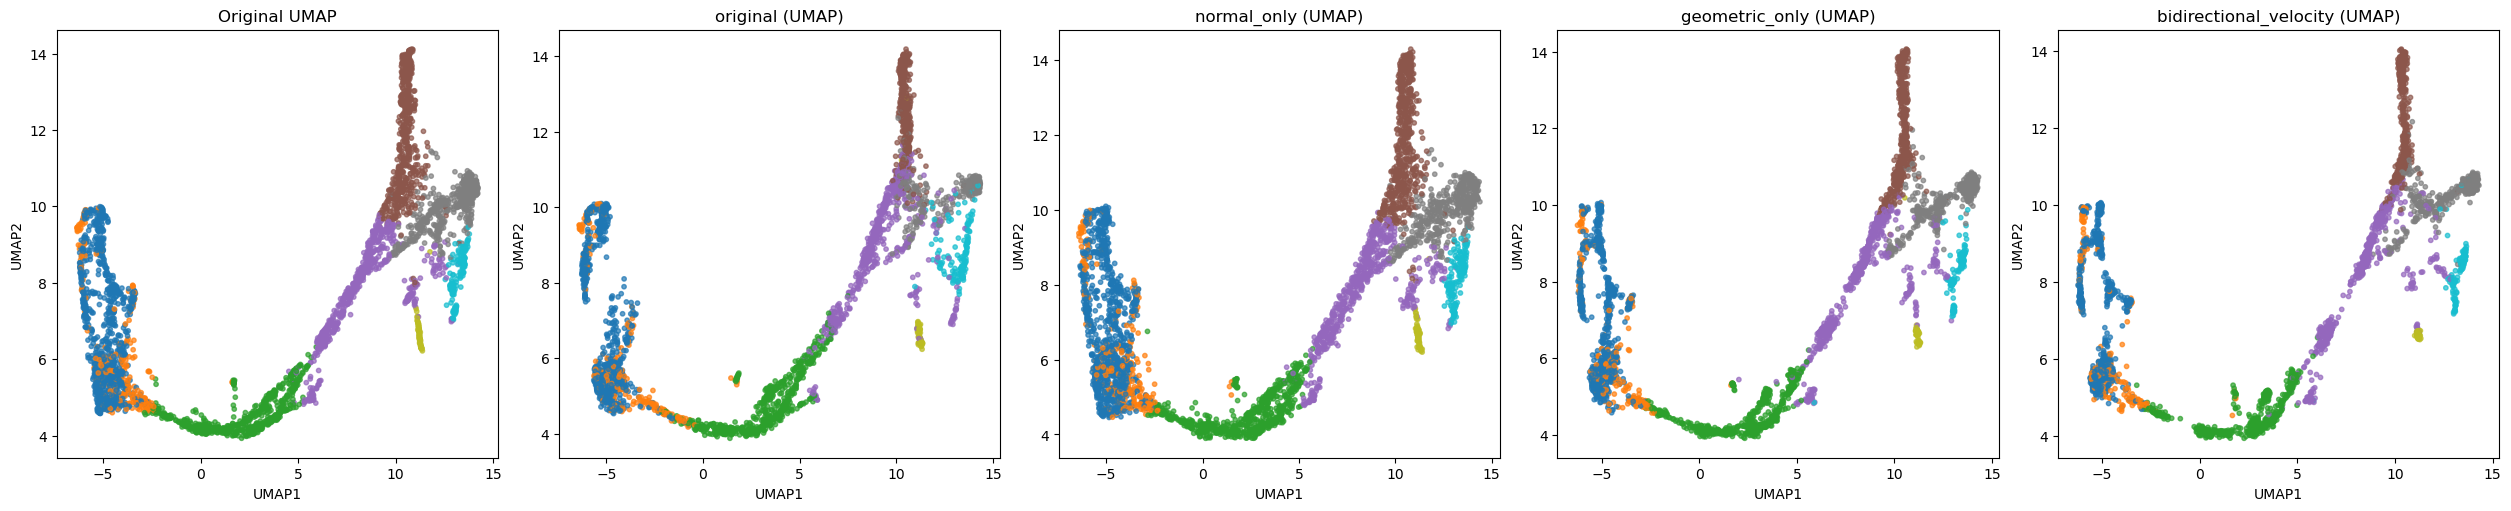

In [20]:
from umap import UMAP

# Compute UMAP for original X
umap_model = UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

# Compute UMAP for each method's Z
results_umap = {}
for name, out in results.items():
    Z = out["Z"]
    Z_umap = umap_model.transform(Z)  # Use same model for consistency
    results_umap[name] = {"Z_umap": Z_umap, "V": out["V"]}  # V is still in high-dim, but we'll plot in UMAP space

def plot_umap_results(X_umap, results_umap, labels):
    ncols = 1 + len(results_umap)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    # Convert categorical labels to numeric codes
    if hasattr(labels, 'cat'):
        color = labels.cat.codes
    else:
        color = labels
    axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
    axes[0].set_title("Original UMAP")
    axes[0].set_xlabel("UMAP1")
    axes[0].set_ylabel("UMAP2")

    for ax, (name, out) in zip(axes[1:], results_umap.items()):
        Z_umap = out["Z_umap"]
        ax.scatter(Z_umap[:, 0], Z_umap[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
        ax.set_title(f"{name} (UMAP)")
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.show()

plot_umap_results(X_umap, results_umap, plot_labels)

## Alternative Visualization: t-SNE Embedding

Use t-SNE for another non-linear dimensionality reduction method to visualize differences.

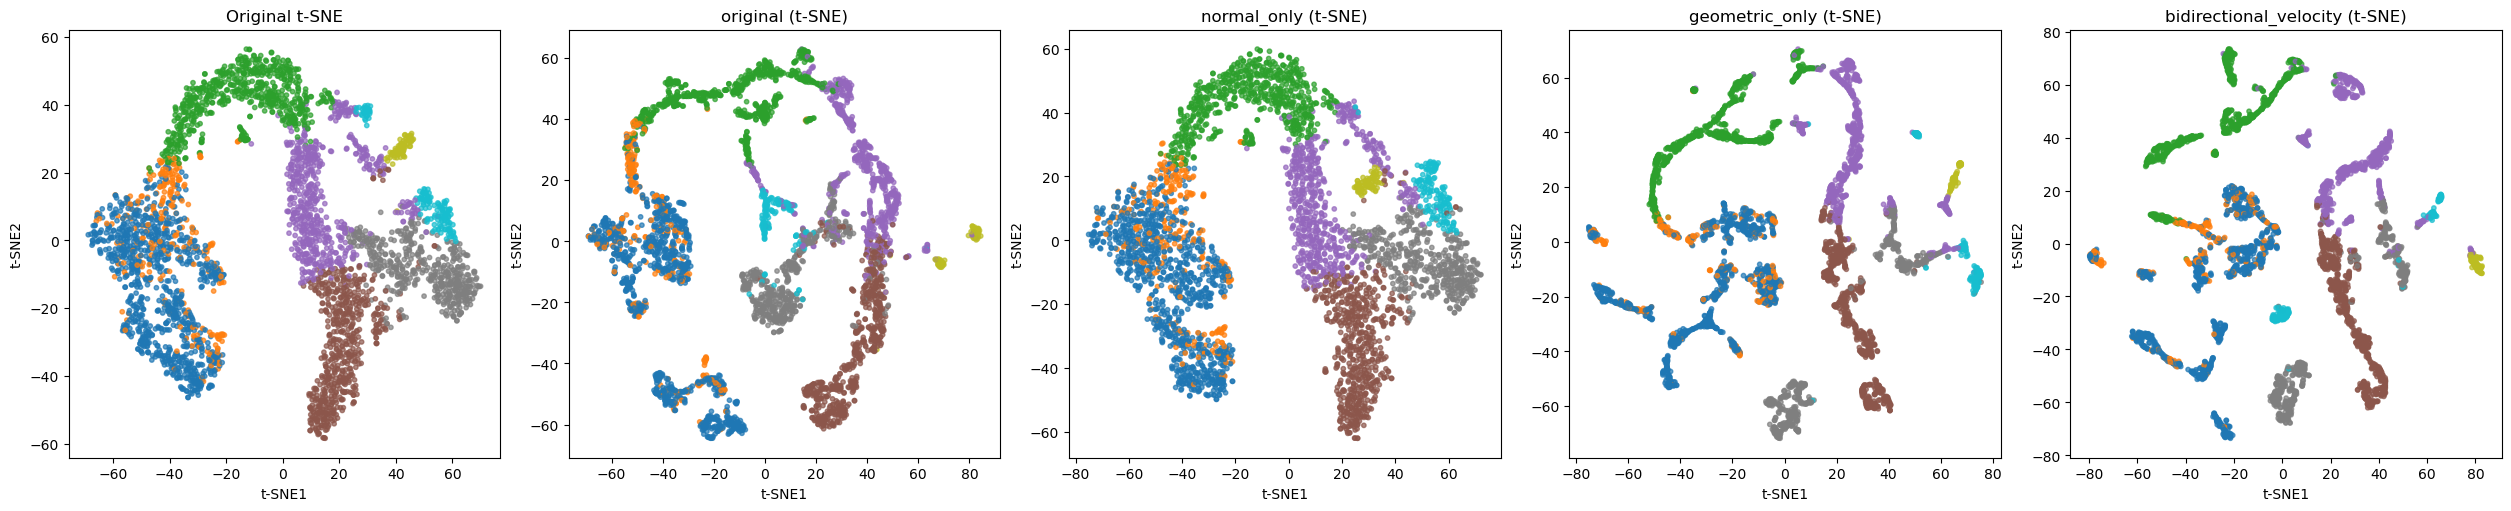

In [21]:
from sklearn.manifold import TSNE

# Compute t-SNE for original X
tsne_model = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate=200.0)
X_tsne = tsne_model.fit_transform(X)

# Compute t-SNE for each method's Z
results_tsne = {}
for name, out in results.items():
    Z = out["Z"]
    Z_tsne = tsne_model.fit_transform(Z)  # Note: t-SNE is not deterministic, but for comparison
    results_tsne[name] = {"Z_tsne": Z_tsne, "V": out["V"]}

def plot_tsne_results(X_tsne, results_tsne, labels):
    ncols = 1 + len(results_tsne)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    # Convert categorical labels to numeric codes
    if hasattr(labels, 'cat'):
        color = labels.cat.codes
    else:
        color = labels
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
    axes[0].set_title("Original t-SNE")
    axes[0].set_xlabel("t-SNE1")
    axes[0].set_ylabel("t-SNE2")

    for ax, (name, out) in zip(axes[1:], results_tsne.items()):
        Z_tsne = out["Z_tsne"]
        ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
        ax.set_title(f"{name} (t-SNE)")
        ax.set_xlabel("t-SNE1")
        ax.set_ylabel("t-SNE2")

    plt.show()

plot_tsne_results(X_tsne, results_tsne, plot_labels)

## Alternative Visualization: scVelo Velocity Embedding

Use scVelo's built-in velocity embedding plots to visualize velocity fields on different bases.

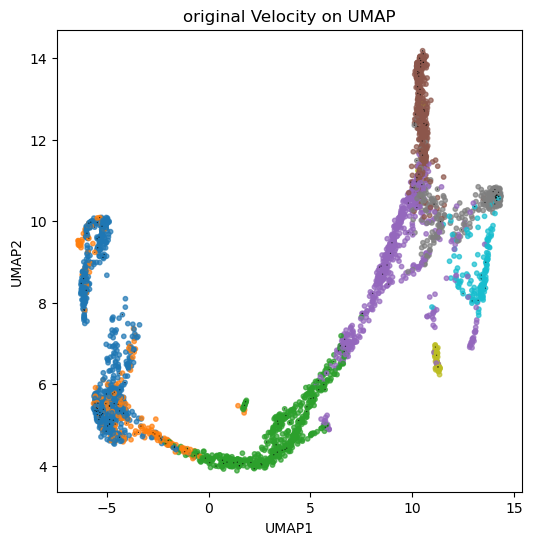

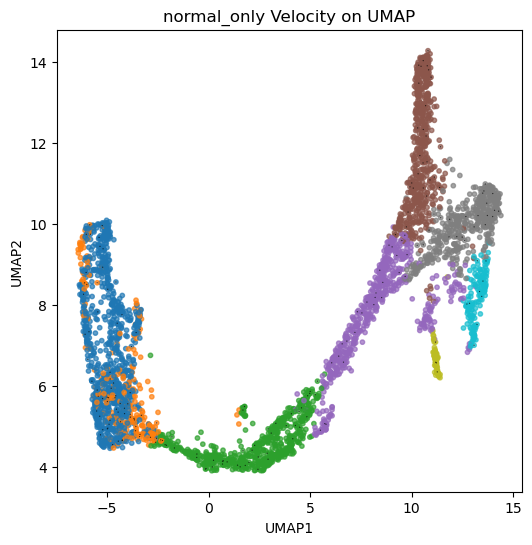

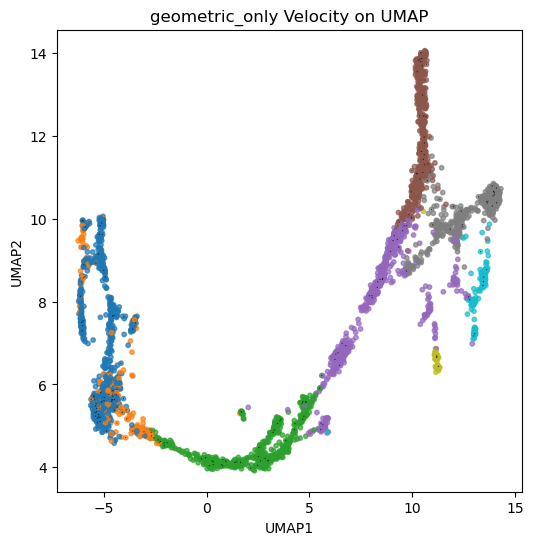

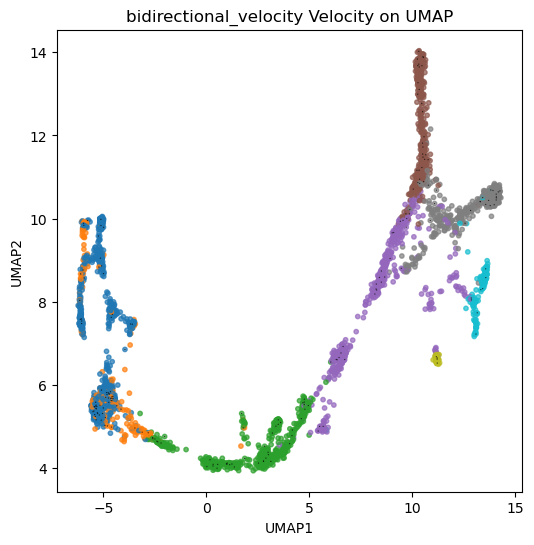

In [22]:
# For scVelo visualization, we need to create adata with updated embeddings
# Note: This is a simplified version; full scVelo integration would require more setup

import scanpy as sc

# Create a copy of original adata (assuming we have it from make_pancreas, but we don't save it)
# For demo, we'll simulate by setting obsm

# Since we don't have adata, we'll use matplotlib to plot velocity on UMAP
# But to use scVelo, we'd need to set adata.obsm['X_umap'] = Z_umap, adata.obsm['velocity_umap'] = projected V

# For simplicity, plot velocity vectors on UMAP embedding
def plot_velocity_on_umap(Z_umap, V, labels, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    if hasattr(labels, 'cat'):
        color = labels.cat.codes
    else:
        color = labels
    ax.scatter(Z_umap[:, 0], Z_umap[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
    # Project V to 2D (simple projection, not accurate)
    V_2d = V[:, :2]  # Assuming V is in same space, but it's not
    step = max(1, Z_umap.shape[0] // 200)
    ax.quiver(
        Z_umap[::step, 0], Z_umap[::step, 1],
        V_2d[::step, 0], V_2d[::step, 1],
        angles="xy", scale_units="xy", scale=50, width=0.003, alpha=0.7
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    plt.show()

# Plot for each method
for name, out in results_umap.items():
    Z_umap = out["Z_umap"]
    V = results[name]["V"]  # Original high-dim V
    plot_velocity_on_umap(Z_umap, V, plot_labels, f"{name} Velocity on UMAP")

# Note: For proper velocity embedding, use scv.tl.velocity_embedding with basis='umap'

## Velocity Field Visualization with scVelo

Use scVelo's built-in functions to visualize velocity as vector fields on embeddings.

Original velocity field on PCA:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

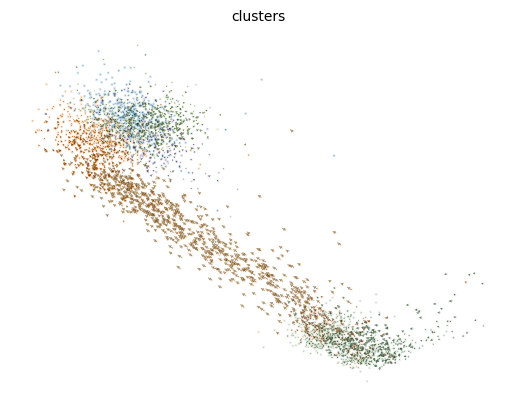

Original velocity field on UMAP:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

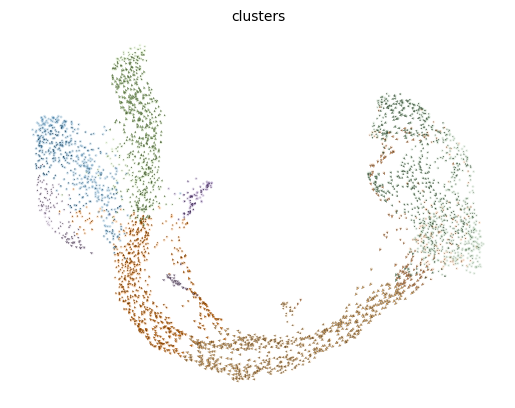

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
original velocity field on PCA:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

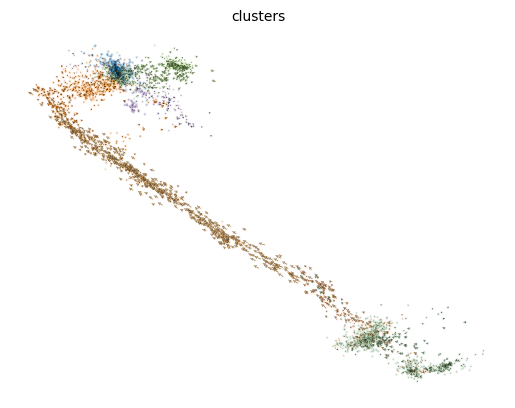

original velocity field on UMAP:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

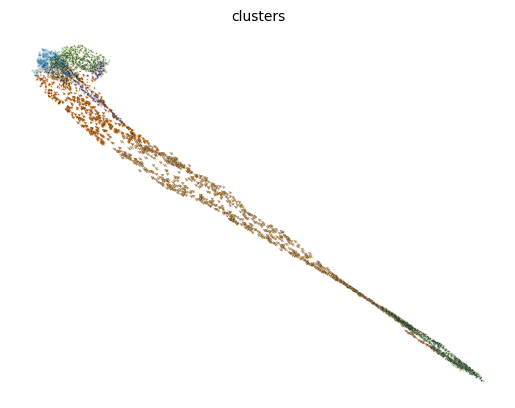

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
normal_only velocity field on PCA:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

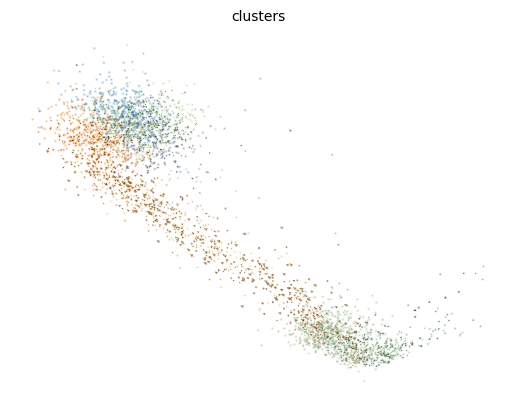

/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

normal_only velocity field on UMAP:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


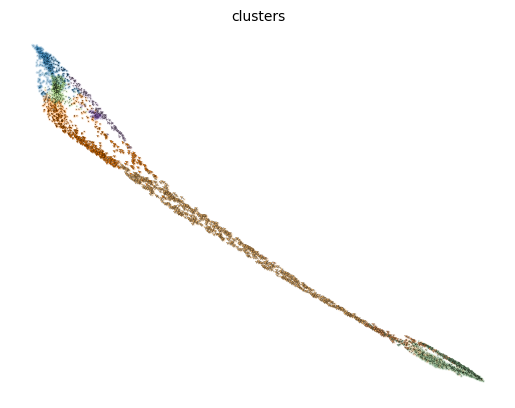

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
geometric_only velocity field on PCA:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

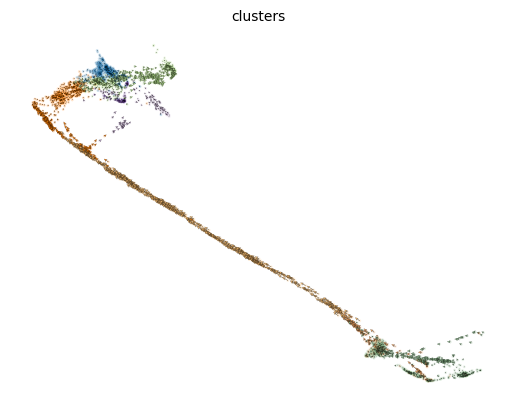

geometric_only velocity field on UMAP:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

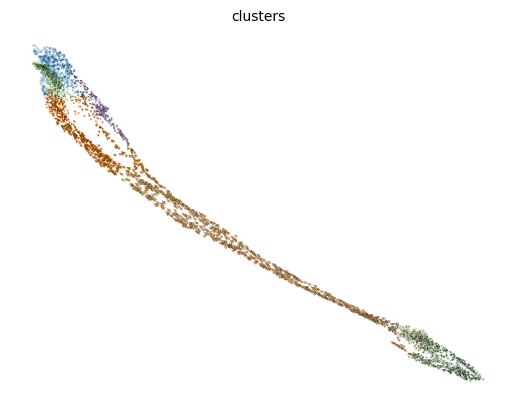

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
bidirectional_velocity velocity field on PCA:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

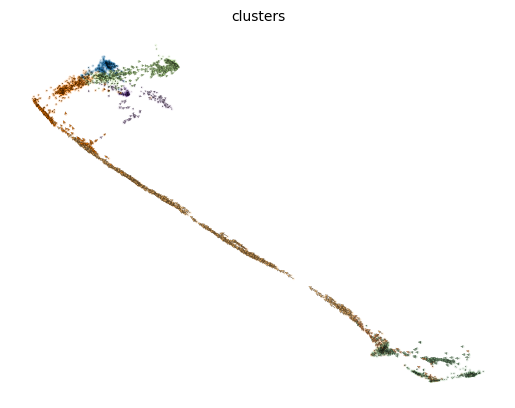

bidirectional_velocity velocity field on UMAP:


/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/opt/anaconda3/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

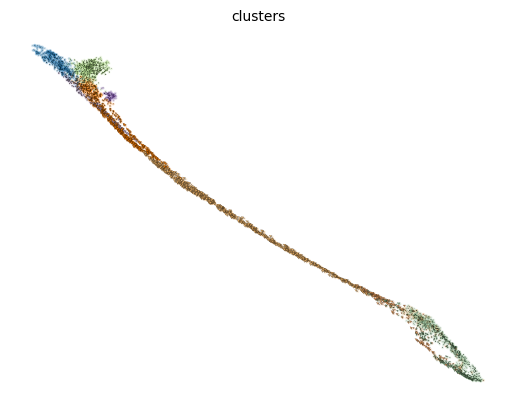

In [23]:
# Visualize original velocity field
print("Original velocity field on PCA:")
scv.pl.velocity_embedding(adata, basis='pca', color='clusters', show=False)
plt.show()

print("Original velocity field on UMAP:")
scv.pl.velocity_embedding(adata, basis='umap', color='clusters', show=False)
plt.show()

# For modified embeddings, we need to update adata
# Create copies for each method
for name, out in results.items():
    adata_copy = adata.copy()
    Z = out["Z"]
    V = out["V"]
    
    # Update PCA embedding
    adata_copy.obsm['X_pca'] = Z
    adata_copy.obsm['velocity_pca'] = V
    
    # Recompute UMAP on new Z
    sc.tl.umap(adata_copy, init_pos='X_pca')  # Use PCA as init
    scv.tl.velocity_embedding(adata_copy, basis='umap')
    
    print(f"{name} velocity field on PCA:")
    scv.pl.velocity_embedding(adata_copy, basis='pca', color='clusters', show=False)
    plt.show()
    
    print(f"{name} velocity field on UMAP:")
    scv.pl.velocity_embedding(adata_copy, basis='umap', color='clusters', show=False)
    plt.show()

## Velocity Field as Streamlines

Interpolate velocity to create streamlines for a continuous vector field visualization.

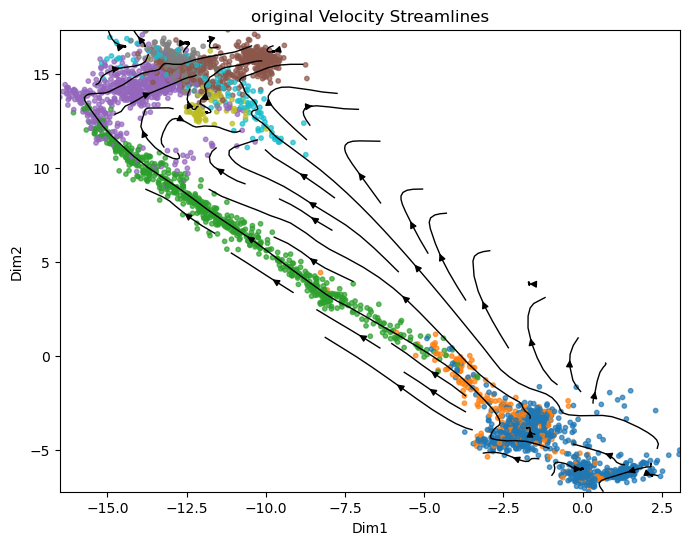

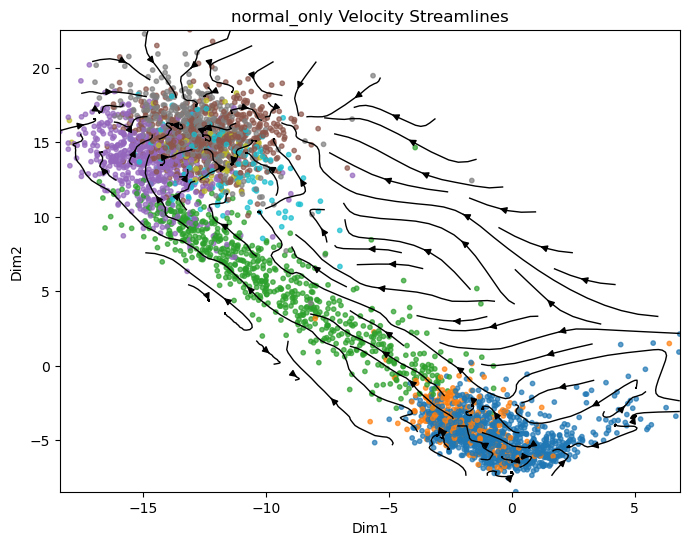

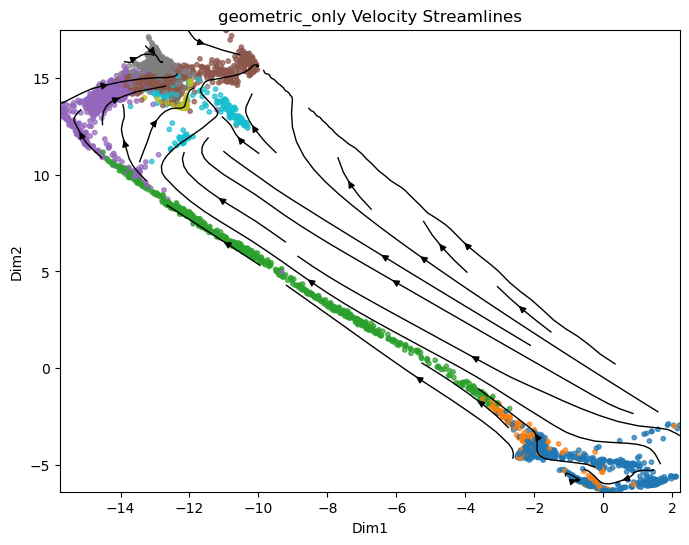

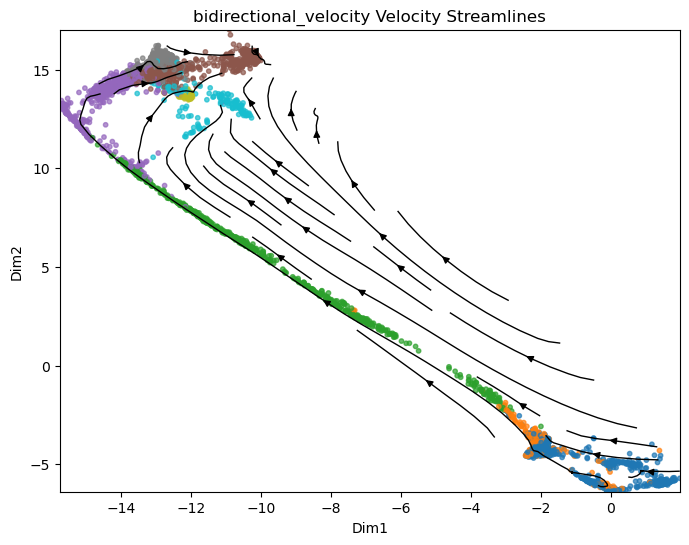

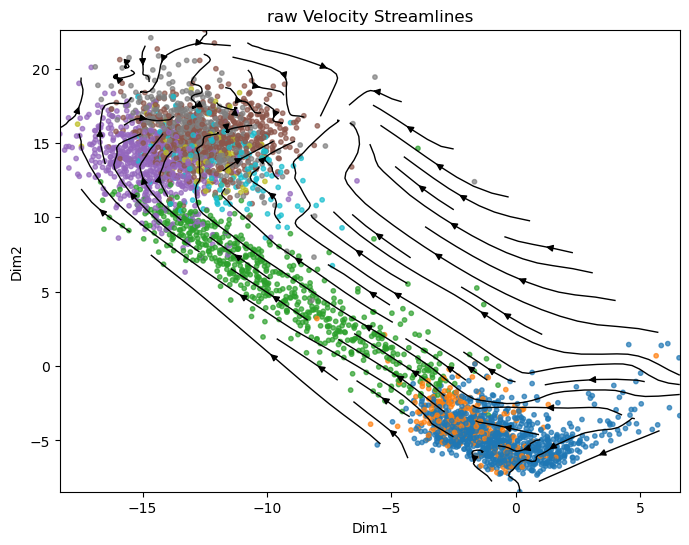

In [33]:
from scipy.interpolate import griddata

def plot_streamlines(Z, V, labels, title):
    # Use first 2 dimensions
    Z_2d = Z[:, :2]
    V_2d = V[:, :2]
    
    # Create grid
    x_min, x_max = Z_2d[:, 0].min(), Z_2d[:, 0].max()
    y_min, y_max = Z_2d[:, 1].min(), Z_2d[:, 1].max()
    # Ensure equally spaced
    x = x_min + np.arange(100) * (x_max - x_min) / 99
    y = y_min + np.arange(100) * (y_max - y_min) / 99
    grid_x, grid_y = np.meshgrid(x, y)
    
    # Interpolate velocity
    u_interp = griddata(Z_2d, V_2d[:, 0], (grid_x, grid_y), method='linear', fill_value=0)
    v_interp = griddata(Z_2d, V_2d[:, 1], (grid_x, grid_y), method='linear', fill_value=0)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Scatter points
    if hasattr(labels, 'cat'):
        color = labels.cat.codes
    else:
        color = labels
    ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=color, s=10, alpha=0.7, cmap='tab10')
    
    # Streamlines
    ax.streamplot(x, y, u_interp, v_interp, density=1, linewidth=1, color='black')
    
    ax.set_title(title)
    ax.set_xlabel("Dim1")
    ax.set_ylabel("Dim2")
    plt.show()

# Plot streamlines for each method
for name, out in results.items():
    Z = out["Z"]
    V = out["V"]
    plot_streamlines(Z, V, plot_labels, f"{name} Velocity Streamlines")

# Also for original
plot_streamlines(X, W, plot_labels, "raw Velocity Streamlines")